# University Admissions — Normal Distribution Analysis

## What This Notebook Is About

This notebook teaches you to work with the **Normal Distribution** (bell curve) — the most important continuous probability distribution in statistics.

---

### The Normal Distribution

The normal distribution describes many real-world quantities: heights, exam scores, measurement errors, returns on investment. It is characterised by just **two parameters**:

| Parameter | Symbol | Meaning |
|---|---|---|
| Mean | μ (mu) | The centre of the bell curve (peak location) |
| Standard deviation | σ (sigma) | How spread out the curve is (narrow = precise, wide = variable) |

We write this as **X ~ N(μ, σ)** — "X is normally distributed with mean μ and standard deviation σ."

---

### Two Types of Problems

This notebook solves both flavours of normal distribution problem:

**1. Forward problem** ("Given a score, find a probability")
- *"What % of applicants score above 600?"*
- Tool: **CDF** (Cumulative Distribution Function) — `scipy.stats.norm.cdf()`
- The CDF gives P(X ≤ x): the probability of scoring AT OR BELOW a given value

**2. Inverse problem** ("Given a probability, find a score")
- *"What score puts someone in the top 15%?"*
- Tool: **PPF** (Percent Point Function, also called the quantile function) — `scipy.stats.norm.ppf()`
- The PPF is the INVERSE of the CDF: given a probability, it returns the corresponding value

---

### The Problem Setup

A university automatically:
- **Accepts** applicants with scores ≥ 600
- **Rejects** applicants with scores ≤ 425
- **Manually reviews** everyone else

Test scores: **N(μ=525, σ=55)**

We first analyse the *existing* thresholds, then redesign them to hit exact acceptance/rejection percentages.

---

### Key Concepts You Will Learn

| Concept | Where |
|---|---|
| Normal distribution PDF: what the bell curve IS | Section 2 |
| CDF: computing tail probabilities | Section 3 |
| PPF: finding scores for given percentages | Section 4 |
| Shading regions under a curve with `fill_between` | Sections 3 & 4 |
| Side-by-side subplots with `plt.subplots(1, 2)` | Section 5 |

---

### Libraries Used
- **`scipy.stats`** — `norm.cdf()`, `norm.ppf()`, `norm.pdf()`: the three key normal distribution functions
- **`numpy`** — `np.linspace()` to generate smooth x-axis values
- **`seaborn`** + **`matplotlib`** — visualisation

## 1. Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

## 2. Define the Distribution

We define our normal distribution N(mu=525, sigma=55).
We also pre-compute an x-axis range spanning +/- 4 standard deviations from the mean --
this covers 99.99% of all possible scores so the tails are not cut off.

In [2]:
# These two numbers DEFINE our distribution — change them to model a different scenario.
mean_score = 525   # μ: the average test score in the applicant population
sd_score   = 55    # σ: the standard deviation (a typical score deviates from the mean by ~55 points)

# np.linspace(start, stop, num): creates `num` evenly spaced values from start to stop.
# We want a smooth curve, so we generate 1000 points spanning ±4 standard deviations.
# Why ±4 SD? Because 99.99% of the distribution falls within μ ± 4σ.
#   → lower bound: 525 - 4×55 = 305
#   → upper bound: 525 + 4×55 = 745
x_range = np.linspace(mean_score - 4*sd_score, mean_score + 4*sd_score, 1000)

# stats.norm.pdf(x, loc, scale):
#   pdf = Probability Density Function — the height of the bell curve at each x.
#   loc   = mean (where the bell is centred)
#   scale = standard deviation (how wide the bell is)
# y_range gives us 1000 (x, y) pairs that trace the bell curve shape.
# NOTE: For a continuous distribution, the PDF height is NOT a probability.
#   The AREA under the curve between two points IS the probability.
y_range = stats.norm.pdf(x_range, mean_score, sd_score)

print(f'Distribution: N(μ={mean_score}, σ={sd_score})')
print(f'Score range plotted: {x_range[0]:.0f} to {x_range[-1]:.0f}')


Distribution: N(μ=525, σ=55)
Score range plotted: 305 to 745


## 3. Forward Problem — Fixed Score Thresholds

### What % of applicants are automatically accepted or rejected?

**The CDF (Cumulative Distribution Function)** answers the question: *"What fraction of the distribution falls BELOW a given value?"*

Formally: **CDF(x) = P(X ≤ x)**

So:
- `stats.norm.cdf(425, 525, 55)` = P(score ≤ 425) → the auto-reject fraction
- `1 - stats.norm.cdf(600, 525, 55)` = P(score ≥ 600) → the auto-accept fraction
  *(We subtract from 1 because the CDF gives "at or below", but we want "above")*

Think of the CDF as measuring the **area under the bell curve to the LEFT** of a point.

In [3]:
# ── CDF CALCULATIONS ──────────────────────────────────────────────────────────
#
# stats.norm.cdf(x, loc, scale)
#   x     = the score threshold
#   loc   = mean of the distribution (μ = 525)
#   scale = standard deviation (σ = 55)
#
# Returns: the CUMULATIVE probability P(X ≤ x)
# Represents: the fraction of applicants scoring AT OR BELOW x.

# P(score ≥ 600): auto-accept fraction
# CDF(600) = P(X ≤ 600) = ~91.4%, so P(X ≥ 600) = 1 − 91.4% = ~8.6%
prob_auto_accept = 1 - stats.norm.cdf(600, mean_score, sd_score)

# P(score ≤ 425): auto-reject fraction
# CDF(425) gives this directly = ~3.5%
prob_auto_reject = stats.norm.cdf(425, mean_score, sd_score)

# Everyone else: 1 − accept − reject = manual review
# (probabilities must sum to 1 = 100%)
prob_manual = 1 - prob_auto_accept - prob_auto_reject

print('--- Approach 1: Fixed Score Thresholds ---')
print(f'  Auto accept  (score >= 600): {prob_auto_accept*100:.2f}%')
print(f'  Auto reject  (score <= 425): {prob_auto_reject*100:.2f}%')
print(f'  Manual review              : {prob_manual*100:.2f}%')


--- Approach 1: Fixed Score Thresholds ---
  Auto accept  (score >= 600): 8.63%
  Auto reject  (score <= 425): 3.45%
  Manual review              : 87.91%


### Visualise -- Original Thresholds

The **green** shaded region = auto-accept tail (right)  
The **red** shaded region = auto-reject tail (left)  
The unshaded middle = manual review zone

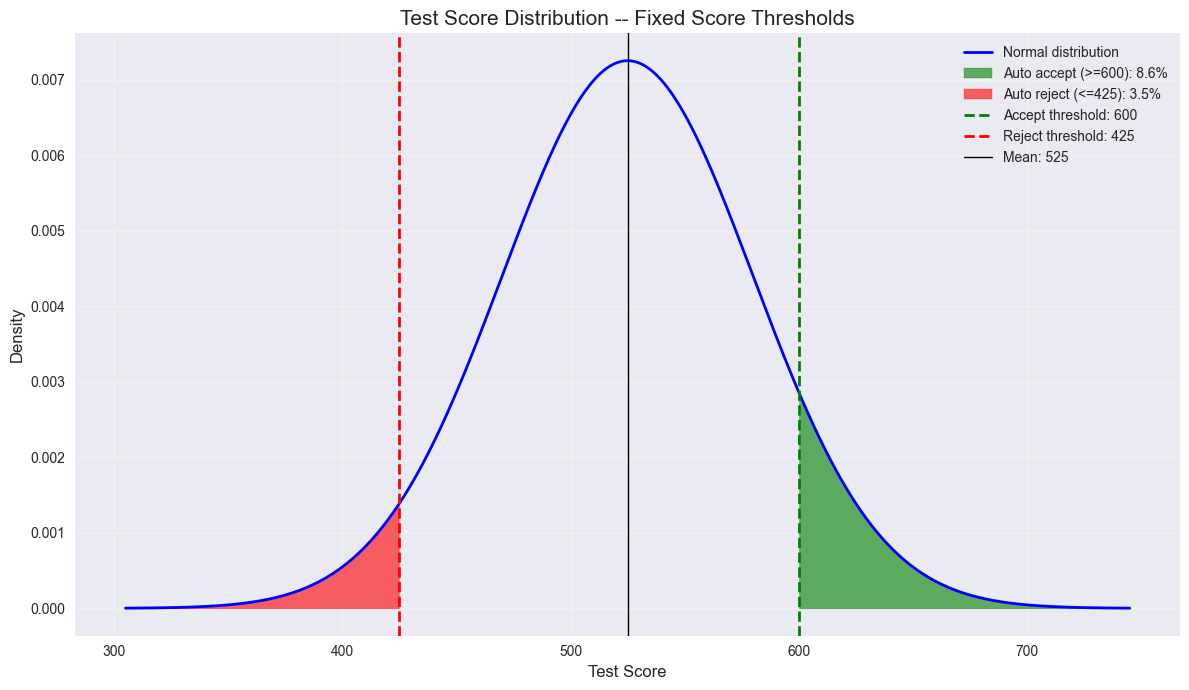

In [4]:
fig, ax = plt.subplots(figsize=(12, 7))

# Main bell curve
sns.lineplot(x=x_range, y=y_range, linewidth=2, label='Normal distribution', color='blue', ax=ax)

# Shade auto-accept region (right tail, score >= 600)
ax.fill_between(x_range, y_range, where=(x_range >= 600),
                alpha=0.6, color='green', label=f'Auto accept (>=600): {prob_auto_accept*100:.1f}%')

# Shade auto-reject region (left tail, score <= 425)
ax.fill_between(x_range, y_range, where=(x_range <= 425),
                alpha=0.6, color='red', label=f'Auto reject (<=425): {prob_auto_reject*100:.1f}%')

# Vertical reference lines at each threshold and the mean
ax.axvline(600,        color='green', linestyle='--', linewidth=2, label='Accept threshold: 600')
ax.axvline(425,        color='red',   linestyle='--', linewidth=2, label='Reject threshold: 425')
ax.axvline(mean_score, color='black', linestyle='-',  linewidth=1, label=f'Mean: {mean_score}')

ax.set_title('Test Score Distribution -- Fixed Score Thresholds', fontsize=15)
ax.set_xlabel('Test Score', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Inverse Problem — Fixed Percentage Thresholds

### What scores correspond to accepting exactly 15% and rejecting exactly 10%?

The **PPF (Percent Point Function)**, also called the **quantile function**, is the **inverse of the CDF**.

- CDF answers: *"Given a score, what fraction score below it?"*
- PPF answers: *"Given a fraction, what score has that many people below it?"*

To accept the **top 15%**: we need the score at the **85th percentile** (85% score below it, 15% above).
→ `stats.norm.ppf(0.85, mean, sd)`

To reject the **bottom 10%**: we need the score at the **10th percentile** (10% score below it).
→ `stats.norm.ppf(0.10, mean, sd)`

**The z-score connection**: `stats.norm.ppf(p)` (without loc/scale) gives the z-score — how many standard deviations from the mean the threshold sits. The actual score = mean + z × sd.

In [5]:
# ── PPF CALCULATIONS (inverse CDF) ───────────────────────────────────────────
#
# stats.norm.ppf(q, loc, scale)
#   q     = the desired cumulative probability (e.g. 0.85 = 85th percentile)
#   loc   = mean (μ = 525)
#   scale = standard deviation (σ = 55)
#
# Returns: the score x such that P(X ≤ x) = q

# Top 15% accepted → threshold at the 85th percentile
# (85% of applicants score BELOW this threshold, 15% score ABOVE it)
x_85 = stats.norm.ppf(0.85, mean_score, sd_score)

# Bottom 10% rejected → threshold at the 10th percentile
# (10% of applicants score BELOW this threshold)
x_10 = stats.norm.ppf(0.10, mean_score, sd_score)

# The z-score: same as above but WITHOUT loc/scale → standardised version.
# A z-score measures "how many standard deviations from the mean".
# z=1.04 means "1.04 SDs above the mean", z=-1.28 means "1.28 SDs below".
# Useful because z-scores are universal: N(0,1) regardless of the original scale.
z_85 = stats.norm.ppf(0.85)    # the z-score for the 85th percentile ≈ 1.04
z_10 = stats.norm.ppf(0.10)    # the z-score for the 10th percentile ≈ -1.28

# Verification: score = mean + z × sd
# x_85 should equal 525 + 1.04 × 55 ≈ 582
# x_10 should equal 525 + (-1.28) × 55 ≈ 454

print('--- Approach 2: Fixed Percentage Thresholds ---')
print(f'  Auto accept 15%:  score >= {x_85:.1f}  (z = {z_85:.4f}, 85th percentile)')
print(f'  Auto reject 10%:  score <= {x_10:.1f}  (z = {z_10:.4f}, 10th percentile)')
print(f'  Manual review:    75.0%  (by design: 100% - 15% - 10%)')


--- Approach 2: Fixed Percentage Thresholds ---
  Auto accept 15%:  score >= 582.0  (z = 1.0364, 85th percentile)
  Auto reject 10%:  score <= 454.5  (z = -1.2816, 10th percentile)
  Manual review:    75.0%  (by design: 100% - 15% - 10%)


### Visualise -- Percentage-Based Thresholds

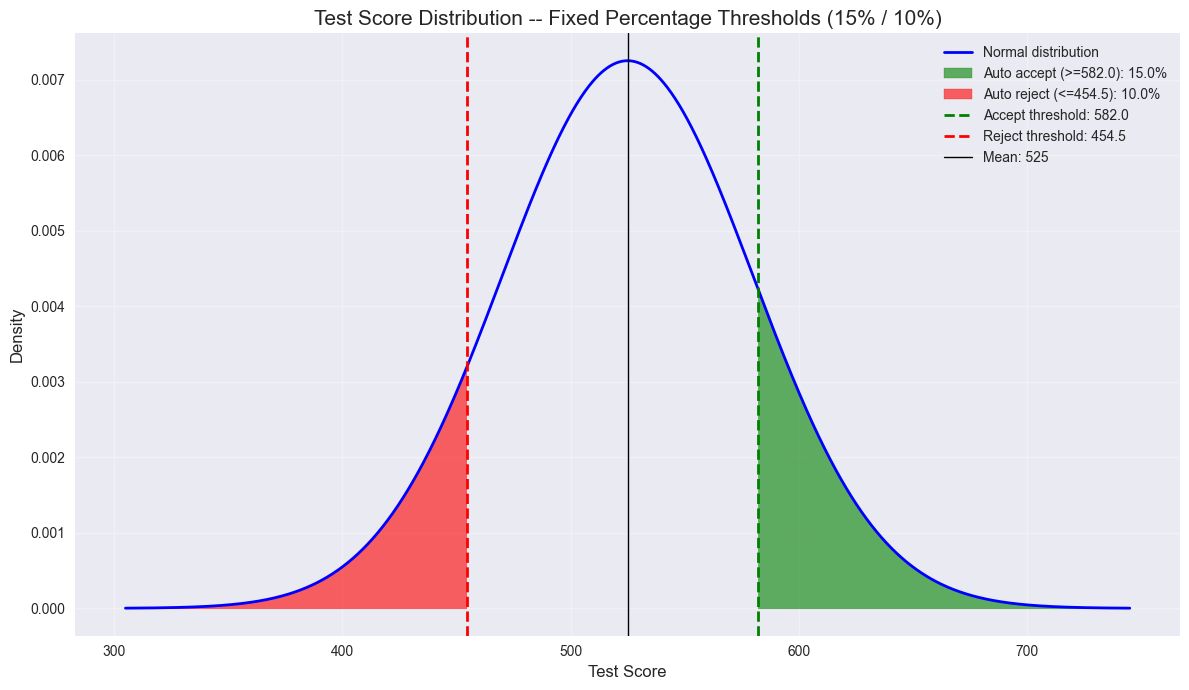

In [6]:
fig, ax = plt.subplots(figsize=(12, 7))

sns.lineplot(x=x_range, y=y_range, linewidth=2, label='Normal distribution', color='blue', ax=ax)

ax.fill_between(x_range, y_range, where=(x_range >= x_85),
                alpha=0.6, color='green', label=f'Auto accept (>={x_85:.1f}): 15.0%')

ax.fill_between(x_range, y_range, where=(x_range <= x_10),
                alpha=0.6, color='red', label=f'Auto reject (<={x_10:.1f}): 10.0%')

ax.axvline(x_85,       color='green', linestyle='--', linewidth=2, label=f'Accept threshold: {x_85:.1f}')
ax.axvline(x_10,       color='red',   linestyle='--', linewidth=2, label=f'Reject threshold: {x_10:.1f}')
ax.axvline(mean_score, color='black', linestyle='-',  linewidth=1, label=f'Mean: {mean_score}')

ax.set_title('Test Score Distribution -- Fixed Percentage Thresholds (15% / 10%)', fontsize=15)
ax.set_xlabel('Test Score', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Side-by-Side Comparison

Plotting both approaches together makes the trade-off visually clear:
- **Left**: fixed score thresholds -> variable % outcomes depending on applicant pool quality
- **Right**: fixed % thresholds -> consistent selection rates, variable score cutoffs

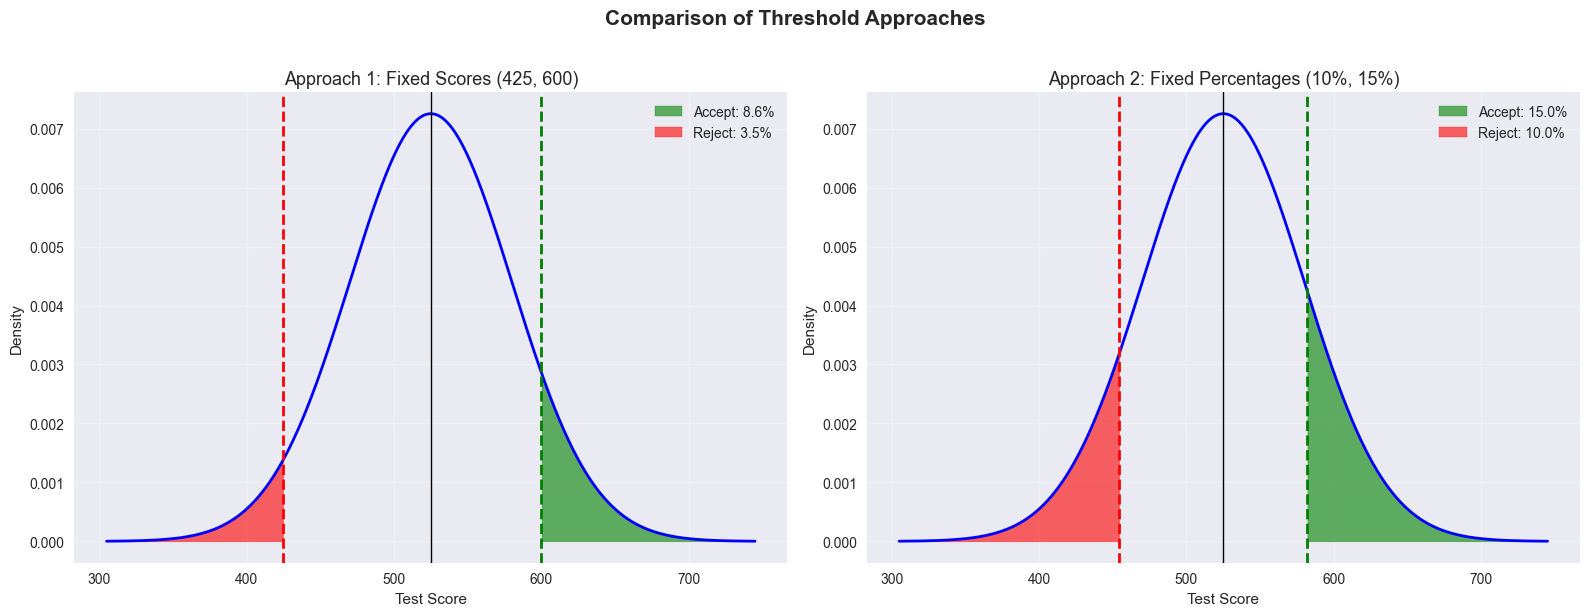

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: original fixed-score approach ---
sns.lineplot(x=x_range, y=y_range, linewidth=2, color='blue', ax=ax1)
ax1.fill_between(x_range, y_range, where=(x_range >= 600),
                 alpha=0.6, color='green', label=f'Accept: {prob_auto_accept*100:.1f}%')
ax1.fill_between(x_range, y_range, where=(x_range <= 425),
                 alpha=0.6, color='red',   label=f'Reject: {prob_auto_reject*100:.1f}%')
ax1.axvline(600,        color='green', linestyle='--', linewidth=2)
ax1.axvline(425,        color='red',   linestyle='--', linewidth=2)
ax1.axvline(mean_score, color='black', linestyle='-',  linewidth=1)
ax1.set_title('Approach 1: Fixed Scores (425, 600)', fontsize=13)
ax1.set_xlabel('Test Score')
ax1.set_ylabel('Density')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Right: percentage-based approach ---
sns.lineplot(x=x_range, y=y_range, linewidth=2, color='blue', ax=ax2)
ax2.fill_between(x_range, y_range, where=(x_range >= x_85),
                 alpha=0.6, color='green', label='Accept: 15.0%')
ax2.fill_between(x_range, y_range, where=(x_range <= x_10),
                 alpha=0.6, color='red',   label='Reject: 10.0%')
ax2.axvline(x_85,       color='green', linestyle='--', linewidth=2)
ax2.axvline(x_10,       color='red',   linestyle='--', linewidth=2)
ax2.axvline(mean_score, color='black', linestyle='-',  linewidth=1)
ax2.set_title('Approach 2: Fixed Percentages (10%, 15%)', fontsize=13)
ax2.set_xlabel('Test Score')
ax2.set_ylabel('Density')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Comparison of Threshold Approaches', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [9]:
import ipywidgets as widgets
from IPython.display import display

%matplotlib inline

mean_score = 525
std_score  = 55
x_range    = np.linspace(mean_score - 4 * std_score, mean_score + 4 * std_score, 400)
y_range    = stats.norm.pdf(x_range, mean_score, std_score)

accept_slider = widgets.IntSlider(value=15, min=1, max=49, step=1,
                                  description='Accept top %',
                                  style={'description_width': '100px'},
                                  layout=widgets.Layout(width='450px'))

reject_slider = widgets.IntSlider(value=10, min=1, max=49, step=1,
                                  description='Reject bottom %',
                                  style={'description_width': '100px'},
                                  layout=widgets.Layout(width='450px'))

out = widgets.Output()

def draw(accept_pct, reject_pct):
    x_accept = stats.norm.ppf(1 - accept_pct / 100, mean_score, std_score)
    x_reject = stats.norm.ppf(reject_pct     / 100, mean_score, std_score)
    review_pct = 100 - accept_pct - reject_pct

    with out:
        out.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(12, 5))

        ax.plot(x_range, y_range, linewidth=2, color='#4a6fa5', label='Normal distribution')
        ax.fill_between(x_range, y_range, where=(x_range >= x_accept),
                        alpha=0.55, color='#2d8a4e',
                        label=f'Auto accept (≥{x_accept:.1f}): {accept_pct}%')
        ax.fill_between(x_range, y_range, where=(x_range <= x_reject),
                        alpha=0.55, color='#c0392b',
                        label=f'Auto reject (≤{x_reject:.1f}): {reject_pct}%')
        ax.fill_between(x_range, y_range,
                        where=((x_range > x_reject) & (x_range < x_accept)),
                        alpha=0.25, color='#6478b4',
                        label=f'Manual review: {review_pct}%')

        
        ax.axvline(x_accept, color='#2d8a4e', linestyle='--', linewidth=1.5)
        ax.text(x_accept, ax.get_ylim()[1] * 0.95, f'{x_accept:.1f}',
                color='#2d8a4e', fontsize=11, fontweight='bold', ha='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#2d8a4e', alpha=0.8))

        ax.axvline(x_reject, color='#c0392b', linestyle='--', linewidth=1.5)
        ax.text(x_reject, ax.get_ylim()[1] * 0.95, f'{x_reject:.1f}',
                color='#c0392b', fontsize=11, fontweight='bold', ha='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#c0392b', alpha=0.8))

        ax.axvline(mean_score, color='#888888', linestyle='-',  linewidth=1,
                   label=f'Mean: {mean_score}')

        ax.set_title(
            f'Test Score Distribution  |  Accept top {accept_pct}%  ·  Reject bottom {reject_pct}%  ·  Review {review_pct}%',
            fontsize=13)
        ax.set_xlabel('Test Score', fontsize=12)
        ax.set_ylabel('Density', fontsize=12)
        ax.legend(fontsize=10, loc='upper left')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

def on_change(change):
    a = accept_slider.value
    r = reject_slider.value
    if a + r > 98:
        if change['owner'] is accept_slider:
            reject_slider.value = max(1, 98 - a)
        else:
            accept_slider.value = max(1, 98 - r)
        return
    draw(a, r)

accept_slider.observe(on_change, names='value')
reject_slider.observe(on_change, names='value')

display(widgets.VBox([accept_slider, reject_slider, out]))
draw(15, 10)

## 6. Summary & Key Insights

In [8]:
manual_original = (1 - prob_auto_accept - prob_auto_reject) * 100
manual_new      = 75.0

print('=' * 65)
print('SUMMARY')
print('=' * 65)

rows = [
    ('Metric',              'Approach 1 (Fixed Scores)', 'Approach 2 (Fixed %)'),
    ('Accept threshold',    '600',                        f'{x_85:.1f} (85th pct)'),
    ('Reject threshold',    '425',                        f'{x_10:.1f} (10th pct)'),
    ('Auto accepted',       f'{prob_auto_accept*100:.1f}%', '15.0%'),
    ('Auto rejected',       f'{prob_auto_reject*100:.1f}%', '10.0%'),
    ('Manual review',       f'{manual_original:.1f}%',      f'{manual_new:.1f}%'),
]

for row in rows:
    print(f'  {row[0]:<22}  {row[1]:<28}  {row[2]}')

print()
print('Key insights:')
print('  - Fixed scores: % outcomes shift if the applicant pool quality changes')
print('  - Fixed %:      consistent selection rates regardless of pool quality')
diff      = abs(manual_original - manual_new)
direction = 'reduces' if manual_original > manual_new else 'increases'
print(f'  - Approach 2 {direction} manual review workload by {diff:.1f} percentage points')
print(f'\n  Distribution assumed: N(mu={mean_score}, sigma={sd_score})')

SUMMARY
  Metric                  Approach 1 (Fixed Scores)     Approach 2 (Fixed %)
  Accept threshold        600                           582.0 (85th pct)
  Reject threshold        425                           454.5 (10th pct)
  Auto accepted           8.6%                          15.0%
  Auto rejected           3.5%                          10.0%
  Manual review           87.9%                         75.0%

Key insights:
  - Fixed scores: % outcomes shift if the applicant pool quality changes
  - Fixed %:      consistent selection rates regardless of pool quality
  - Approach 2 reduces manual review workload by 12.9 percentage points

  Distribution assumed: N(mu=525, sigma=55)
